# U4A1 — Análisis de Eventos Aleatorios mediante Procesos de Poisson


In [ ]:
# --- Librerías ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams.update({'figure.dpi':110,'font.size':10,'axes.grid':True,'grid.alpha':.3})
AZ, NA, VE = '#1f4e79', '#c55a11', '#548235'

## Parte 1. Análisis exploratorio de datos


In [ ]:

df = pd.read_csv('estado_de_red.csv')
display(df.head())

print('\nVariables disponibles:')
for c in df.columns:
    print(f'  - {c}: {df[c].dtype}')

,id_evento,tiempo_horas,dia,hora,estado_red,intervalo_min
0,1,0.116543,1,0.116543,R,0.00
1,2,1.263048,1,1.263048,C,68.79
2,3,1.310808,1,1.310808,C,2.87
3,4,1.684345,1,1.684345,N,22.41
4,5,1.685162,1,1.685162,N,0.05



Variables disponibles:
  - id_evento: int64
  - tiempo_horas: float64
  - dia: int64
  - hora: float64
  - estado_red: object
  - intervalo_min: float64


In [ ]:

descripcion = {
 'id_evento':'Identificador único del evento',
 'tiempo_horas':'Tiempo acumulado desde el inicio del estudio (horas)',
 'dia':'Día de observación (1 a 30)',
 'hora':'Hora del día en que ocurrió el evento (0 a 24, fraccionaria)',
 'estado_red':'Estado tras el evento: N=Normal, C=Congestionada, R=Crítica',
 'intervalo_min':'Minutos transcurridos desde la falla anterior'
}
for k,v in descripcion.items():
    print(f'{k:15s}: {v}')

id_evento      : Identificador único del evento
tiempo_horas   : Tiempo acumulado desde el inicio del estudio (horas)
dia            : Día de observación (1 a 30)
hora           : Hora del día en que ocurrió el evento (0 a 24, fraccionaria)
estado_red     : Estado tras el evento: N=Normal, C=Congestionada, R=Crítica
intervalo_min  : Minutos transcurridos desde la falla anterior


In [ ]:
# Número total de eventos
n_total = len(df)
dias = int(df.dia.max())
T_horas = float(df.tiempo_horas.max())
print(f'Número total de eventos registrados: {n_total}')
print(f'Días de observación: {dias}')
print(f'Duración total: {T_horas:.1f} horas')
print(f'Estado de la red:', df.estado_red.value_counts().to_dict())

Número total de eventos registrados: 3649
Días de observación: 30
Duración total: 720.0 horas
Estado de la red: {'N': 2557, 'C': 713, 'R': 379}


In [ ]:
# Estadísticas descriptivas de las variables numéricas
df[['tiempo_horas','dia','hora','intervalo_min']].describe().round(3)

,tiempo_horas,dia,hora,intervalo_min
count,3649.000,3649.000,3649.000,3649.000
mean,364.601,15.582,14.637,11.837
std,209.012,8.707,6.396,14.337
min,0.117,1.000,0.031,0.000
25%,186.888,8.000,9.481,2.840
50%,359.725,15.000,15.568,7.220
75%,548.967,23.000,20.173,15.350
max,719.993,30.000,23.993,167.920


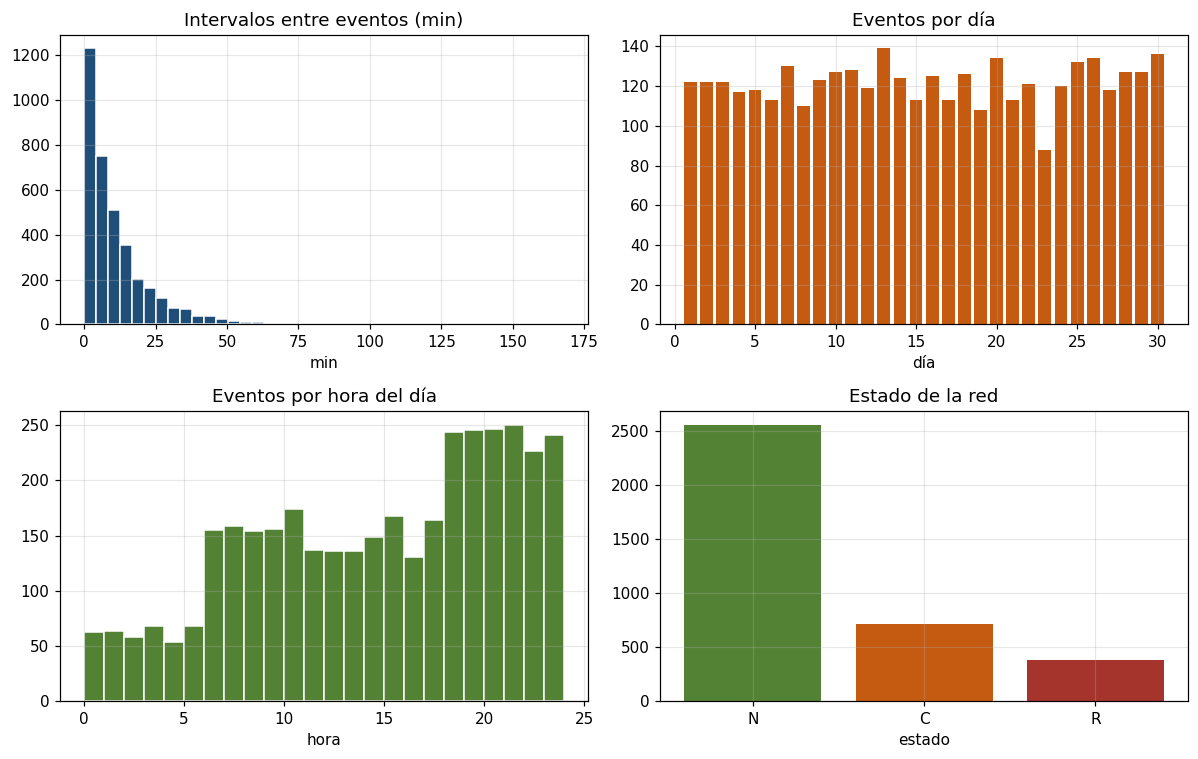

In [ ]:
# Visualizaciones
fig, ax = plt.subplots(2, 2, figsize=(11,7))
ax[0,0].hist(df.intervalo_min, bins=40, color=AZ, edgecolor='white')
ax[0,0].set_title('Intervalos entre eventos (min)'); ax[0,0].set_xlabel('min')

eb = df.groupby('dia').size()
ax[0,1].bar(eb.index, eb.values, color=NA)
ax[0,1].set_title('Eventos por día'); ax[0,1].set_xlabel('día')

ax[1,0].hist(df.hora, bins=24, color=VE, edgecolor='white')
ax[1,0].set_title('Eventos por hora del día'); ax[1,0].set_xlabel('hora')

vc = df.estado_red.value_counts()
ax[1,1].bar(vc.index, vc.values, color=[VE,NA,'#a5342d'])
ax[1,1].set_title('Estado de la red'); ax[1,1].set_xlabel('estado')
plt.tight_layout(); plt.show()

## Parte 2. Estudio de la Distribución de Poisson


In [ ]:
# Conteo de eventos por cada hora del periodo
bins = np.arange(0, 721, 1)
counts, _ = np.histogram(df.tiempo_horas, bins=bins)

lam = counts.mean()
var = counts.var()
print(f'λ estimada (eventos/hora): {lam:.3f}')
print(f'Media de los conteos:      {lam:.3f}')
print(f'Varianza de los conteos:   {var:.3f}')
print(f'Razón varianza/media:      {var/lam:.3f}')

λ estimada (eventos/hora): 5.068
Media de los conteos:      5.068
Varianza de los conteos:   9.680
Razón varianza/media:      1.910


In [ ]:
# Prueba chi-cuadrado de bondad de ajuste a Poisson
kmax = int(counts.max())
ks = np.arange(0, kmax+1)
fo = np.array([(counts==k).sum() for k in ks])
fe = stats.poisson.pmf(ks, lam) * len(counts)
chi, pchi = stats.chisquare(fo, fe*fo.sum()/fe.sum())
print(f'Chi-cuadrado: {chi:.2f}')
print(f'Valor-p:      {pchi:.2e}')
print('El ajuste Poisson homogéneo se rechaza.')

Chi-cuadrado: 427.36
Valor-p:      6.60e-81
El ajuste Poisson homogéneo se rechaza.


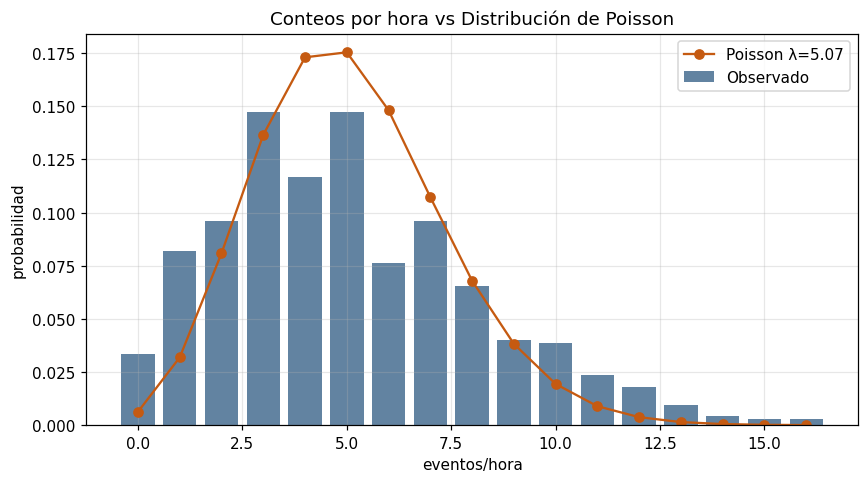

In [ ]:
obs = np.array([(counts==k).mean() for k in ks])
teo = stats.poisson.pmf(ks, lam)
fig, ax = plt.subplots(figsize=(8,4.5))
ax.bar(ks, obs, color=AZ, alpha=.7, label='Observado')
ax.plot(ks, teo, 'o-', color=NA, label=f'Poisson λ={lam:.2f}')
ax.set_title('Conteos por hora vs Distribución de Poisson')
ax.set_xlabel('eventos/hora'); ax.set_ylabel('probabilidad'); ax.legend()
plt.tight_layout(); plt.show()

## Parte 3. Análisis de los tiempos entre eventos


In [ ]:
# Intervalos entre eventos
iv = df.intervalo_min.values[1:]
iv = iv[iv >= 0]

media_iv = iv.mean()
lam_exp = 1/media_iv
print(f'Media de intervalos (min):        {media_iv:.3f}')
print(f'Desviación estándar (min):        {iv.std():.3f}')
print(f'λ exponencial (1/media) por min:  {lam_exp:.4f}')

# Prueba Kolmogórov-Smirnov
ks_stat, ks_p = stats.kstest(iv, 'expon', args=(0, media_iv))
print(f'K-S estadístico: {ks_stat:.4f}  |  p = {ks_p:.2e}')

Media de intervalos (min):        11.840
Desviación estándar (min):        14.336
λ exponencial (1/media) por min:  0.0845
K-S estadístico: 0.0477  |  p = 1.19e-07


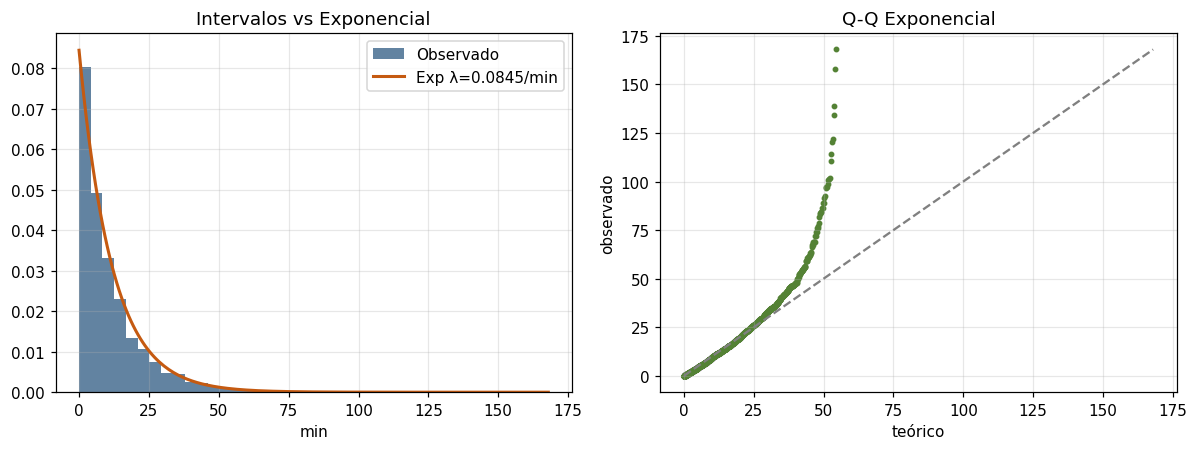

In [ ]:
# Comparación gráfica
fig, ax = plt.subplots(1, 2, figsize=(11,4.2))
x = np.linspace(0, iv.max(), 200)
ax[0].hist(iv, bins=40, density=True, color=AZ, alpha=.7, label='Observado')
ax[0].plot(x, lam_exp*np.exp(-lam_exp*x), color=NA, lw=2, label=f'Exp λ={lam_exp:.4f}/min')
ax[0].set_title('Intervalos vs Exponencial'); ax[0].set_xlabel('min'); ax[0].legend()

theo_q = stats.expon.ppf(np.linspace(.01,.99,len(iv)), scale=media_iv)
ax[1].scatter(np.sort(theo_q), np.sort(iv), s=8, color=VE)
lims = [0, max(iv.max(), theo_q.max())]
ax[1].plot(lims, lims, '--', color='gray')
ax[1].set_title('Q-Q Exponencial'); ax[1].set_xlabel('teórico'); ax[1].set_ylabel('observado')
plt.tight_layout(); plt.show()

In [ ]:
P_mayor_30 = np.exp(-lam_exp*30)
P_menor_5  = 1 - np.exp(-lam_exp*5)
P_10_20    = np.exp(-lam_exp*10) - np.exp(-lam_exp*20)
print(f'P(espera > 30 min)          = {P_mayor_30:.4f}  ({P_mayor_30*100:.1f}%)')
print(f'P(espera < 5 min)           = {P_menor_5:.4f}  ({P_menor_5*100:.1f}%)')
print(f'P(10 min < espera < 20 min) = {P_10_20:.4f}  ({P_10_20*100:.1f}%)')

P(espera > 30 min)          = 0.0794  (7.9%)
P(espera < 5 min)           = 0.3445  (34.4%)
P(10 min < espera < 20 min) = 0.2451  (24.5%)


## Parte 4. Identificación de un Proceso de Poisson No Homogéneo


In [ ]:
# λ por franja horaria
def franja(h):
    if h < 6:  return '00-06'
    if h < 18: return '06-18'
    return '18-24'

df['franja'] = df.hora.apply(franja)
horas_franja = {'00-06':6, '06-18':12, '18-24':6}
lam_franja = {}
for f, hspan in horas_franja.items():
    n = (df.franja==f).sum()
    lam_franja[f] = n/(hspan*dias)
    print(f'Franja {f}: λ = {lam_franja[f]:.3f} eventos/hora')

Franja 00-06: λ = 2.056 eventos/hora
Franja 06-18: λ = 5.067 eventos/hora
Franja 18-24: λ = 8.083 eventos/hora


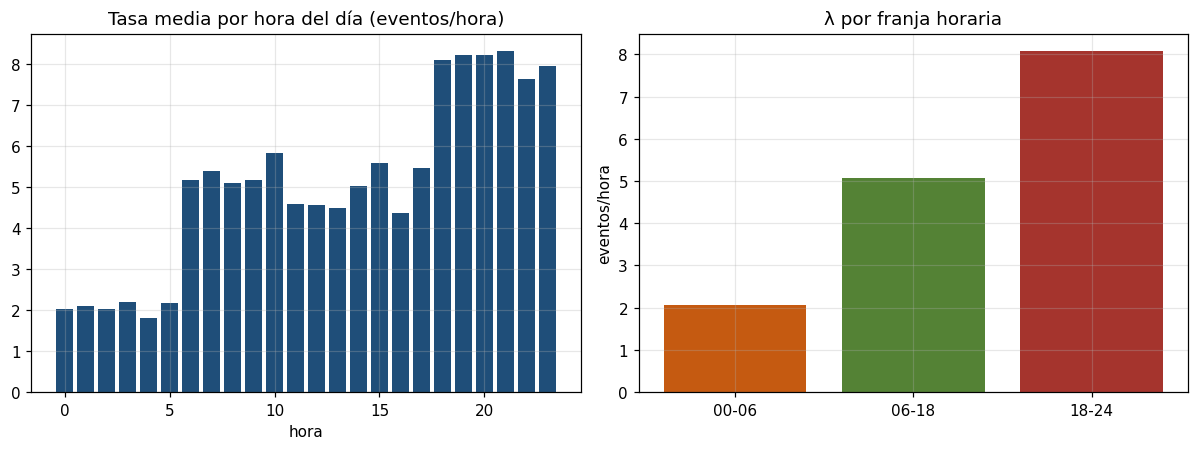

In [ ]:
# Gráficas de evolución temporal
perfil = df.groupby(df.hora.astype(int)).size()/dias
fig, ax = plt.subplots(1, 2, figsize=(11,4.2))
ax[0].bar(perfil.index, perfil.values, color=AZ)
ax[0].set_title('Tasa media por hora del día (eventos/hora)'); ax[0].set_xlabel('hora')
ax[1].bar(lam_franja.keys(), lam_franja.values(), color=[NA,VE,'#a5342d'])
ax[1].set_title('λ por franja horaria'); ax[1].set_ylabel('eventos/hora')
plt.tight_layout(); plt.show()

In [ ]:
# Prueba chi-cuadrado de homogeneidad
obs_f = np.array([(df.franja==f).sum() for f in horas_franja])
exp_f = np.array([horas_franja[f] for f in horas_franja], float)
exp_f = exp_f/exp_f.sum()*obs_f.sum()
chi_f, p_f = stats.chisquare(obs_f, exp_f)
print(f'Chi-cuadrado de homogeneidad: {chi_f:.1f}')
print(f'Valor-p: {p_f:.2e}')
print('Proceso NO homogéneo.')

Chi-cuadrado de homogeneidad: 645.2
Valor-p: 7.76e-141
Proceso NO homogéneo.


El proceso es NO homogéneo.

## Parte 5. Simulación del proceso


In [ ]:
# Simulación de un NHPP por thinning
rng = np.random.default_rng(42)
lam_h = np.array([(df.hora.astype(int)==h).sum()/dias for h in range(24)])
lam_max = lam_h.max()

T = 720
sim = []
t = 0
while t < T:
    t += rng.exponential(1/lam_max)
    if t >= T: break
    h = int(t % 24)
    if rng.random() < lam_h[h]/lam_max:
        sim.append(t)
sim = np.array(sim)
sim_iv = np.diff(sim)*60

print(f'Eventos reales:    {n_total}')
print(f'Eventos simulados: {len(sim)}')
print(f'Media eventos/día real: {df.groupby("dia").size().mean():.1f} | sim: {len(sim)/30:.1f}')
print(f'Media intervalo real: {media_iv:.2f} min | sim: {sim_iv.mean():.2f} min')

Eventos reales:    3649
Eventos simulados: 3639
Media eventos/día real: 121.6 | sim: 121.3
Media intervalo real: 11.84 min | sim: 11.85 min


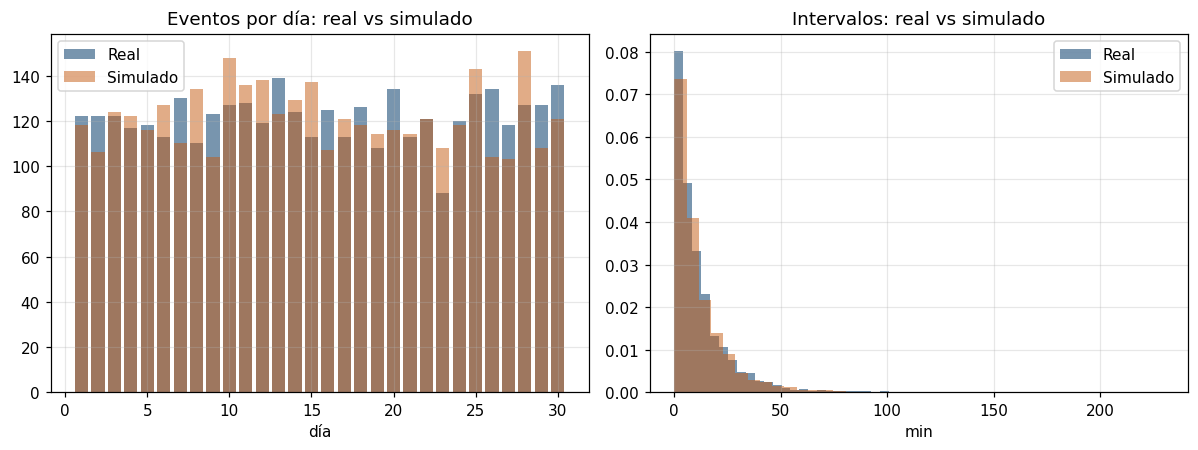

In [ ]:
# Comparación real vs simulado
fig, ax = plt.subplots(1, 2, figsize=(11,4.2))
real_dias = df.groupby('dia').size().reindex(range(1,31), fill_value=0).values
sim_dias = pd.Series((sim//24+1).astype(int)).value_counts().reindex(range(1,31), fill_value=0).values
ax[0].bar(np.arange(1,31), real_dias, alpha=.6, color=AZ, label='Real')
ax[0].bar(np.arange(1,31), sim_dias, alpha=.5, color=NA, label='Simulado')
ax[0].set_title('Eventos por día: real vs simulado'); ax[0].set_xlabel('día'); ax[0].legend()

ax[1].hist(df.intervalo_min[1:], bins=40, density=True, alpha=.6, color=AZ, label='Real')
ax[1].hist(sim_iv, bins=40, density=True, alpha=.5, color=NA, label='Simulado')
ax[1].set_title('Intervalos: real vs simulado'); ax[1].set_xlabel('min'); ax[1].legend()
plt.tight_layout(); plt.show()

La simulación reproduce el volumen total de eventos, la media por día 121 y la distribución de intervalos 11.8 min.

Por su naturaleza aleatoria, la variación día a día no coincide con los datos reales. El modelo captura la estructura estadística.

## Conclusión
Las fallas de la red se modelan como un Proceso de Poisson No Homogéneo. Los tiempos entre eventos son exponenciales y los conteos son de tipo Poisson, pero la tasa de ocurrencia varía según la hora del día (de 2 a 8 eventos/hora). La simulación con tasa variable reproduce el comportamiento observado.